In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('US Superstore data.xls')

data.head()
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

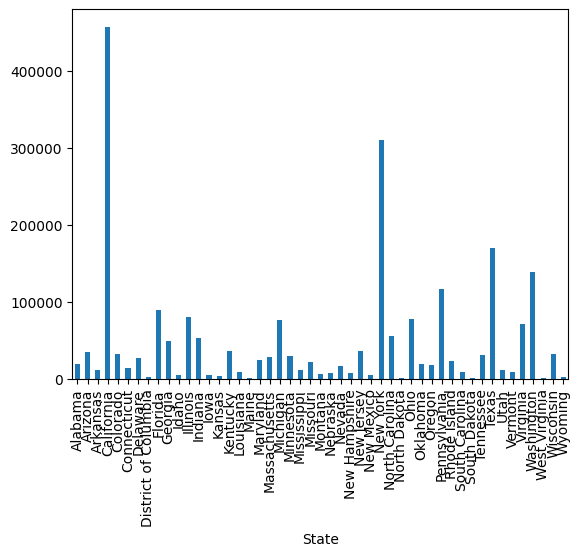

In [20]:
State = data['State']
Sales = data['Sales']

sales_by_state = data.groupby("State")["Sales"].sum()

sales_by_state.plot(kind="bar")
plt.show()

# California (457,687), New York (310,876), Texas (170,188) and Washington (138,641) are 
# the top selling states as can be seen in the bar chart below


In [24]:
profit_by_state = data.groupby("State")["Profit"].sum()

california_sales = sales_by_state["California"]
New_York_sales = sales_by_state["New York"]

california_profit = profit_by_state["California"]
New_York_profit = profit_by_state["New York"]

print(f"The difference in sales between California and New York is : {(california_sales - New_York_sales):.2f}")
print(f"The difference in profits between California and New York is : {(california_profit - New_York_profit):.2f}")

The difference in sales between California and New York is : 146811.36
The difference in profits between California and New York is : 2342.84


In [45]:
ny_customers = data[data["State"] == "New York"]
sales_by_ny_customers = ny_customers.groupby("Customer ID")["Sales"].sum()

best_customer = sales_by_ny_customers.idxmax()
total_sales = sales_by_ny_customers.max()

print(f"The Best Customer in New York is : {best_customer} with total sales of: {total_sales:.2f}")



The Best Customer in New York is : TA-21385 with total sales of: 13723.50


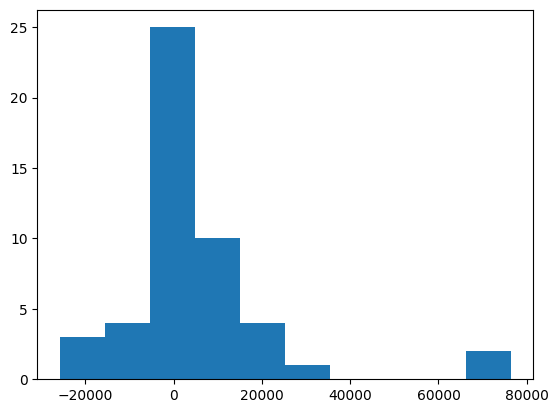

In [59]:
profit_by_state = data.groupby("State")["Profit"].sum()

plt.hist(profit_by_state)
plt.show()


In [60]:
worst_state = profit_by_state.idxmin()
min_profit = profit_by_state.min()
print(f"{worst_state}    {min_profit:.2f}")

best_state = profit_by_state.idxmax()
max_profit = profit_by_state.max()
print(f"{best_state}    {max_profit:.2f}")


Texas    -25729.36
California    76381.39


In [ ]:
# As we can see some atates have negative profits (Texas) while others have high profits 
# (California - which may be an outlier)

In [ ]:
# Determine if 20% of the customers contribute to 80% of the profit.)

# aggregate all profits
# aggregate to 20% profits from customers



In [ ]:
profit_by_customers = data.groupby("Customer ID")["Profit"].sum()

total_profit = sum(profit_by_customers)
profit80 = total_profit * 0.8
print(f"{profit80:.2f}")

sorted_customers = sorted(profit_by_customers, reverse=True)
top20 = sorted_customers[:int(len(sorted_customers) * 0.2)]
total_20profit = sum(top20)

if total_20profit >= profit80:
    print(f"Pareto Works ! \n20% of the Customers account for {total_20profit:.2f}, which is more than 80% of the total profit which is: {profit80:.2f}")
else:
    print(f"Pareto DOES NOT Work !!! \n20% of the Customers account for only {total_20profit:.2f}, which is lss than 80% of the total profit which is: {profit80:.2f}")


229117.62
Pareto Works ! 
20% of the Customers account for 233201.28, which is more than 80% of the total profit which is: 229117.62


In [ ]:
# What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? 
# Are there any difference among cities in profitability ? (Identify the top 20 cities based 
# on total sales and total profit and analyze differences in profitability among these cities.)

Top 20 Cities in sales:
 City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64
Top 20 Cities in profits: 
 City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          589

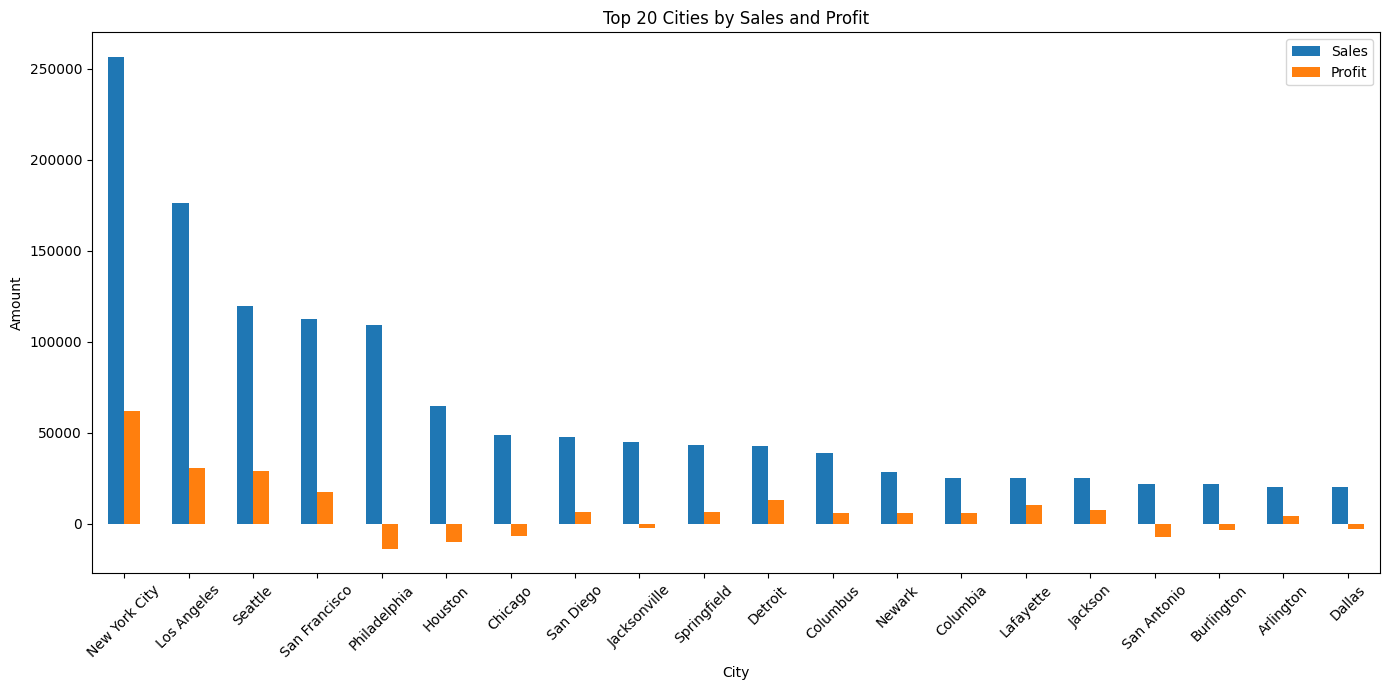

In [ ]:
profit_by_cities = data.groupby("City")["Profit"].sum()
sales_by_cities = data.groupby("City")["Sales"].sum()

top20_profits = profit_by_cities.nlargest(20)
top20_sales = sales_by_cities.nlargest(20)

print(f"Top 20 Cities in sales:\n {top20_sales}")
print(f"Top 20 Cities in profits: \n {top20_profits}")

city_summary = data.groupby("City").agg({
    "Sales": "sum",
    "Profit": "sum"
})

top20 = city_summary.nlargest(20, "Sales")

top20.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Top 20 Cities by Sales and Profit")
plt.xlabel("City")
plt.ylabel("Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# As can be seen below some cities have a much higher profitability 
# compared with the overall sales (Detroit, Laffayette, Jackson).

In [ ]:
# What are the Top 20 customers by Sales?

sales_by_customers = data.groupby("Customer ID")["Sales"].sum()
top20_customers = sales_by_customers.nlargest(20)
print(top20_customers)

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
TS-21370    11891.751
GT-14710    11820.120
BM-11140    11789.630
SV-20365    11470.950
CJ-12010    11164.974
CL-12565    10880.546
ME-17320    10663.728
KF-16285    10604.266
BS-11365    10501.653
EH-13765    10310.880
Name: Sales, dtype: float64


In [ ]:
# Plot the Cumulative curve in Sales by Customers. 
# Can we apply Pareto principle to customers and Sales ?

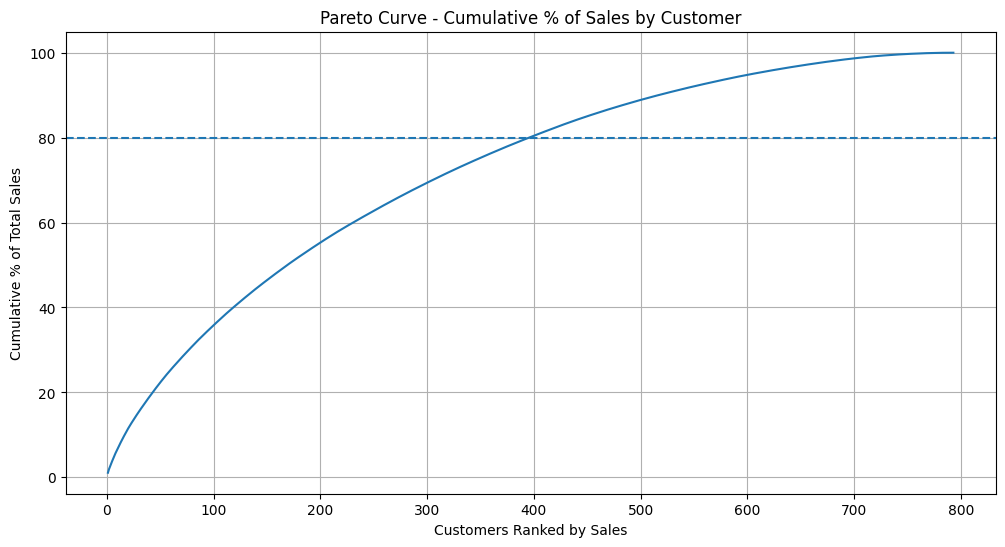

In [101]:
customer_sales = data.groupby("Customer ID")["Sales"].sum()
customer_sales = customer_sales.sort_values(ascending=False)
cumulative_sales = customer_sales.cumsum()

customer_sales = (
    data.groupby("Customer ID")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

cumulative_pct = (
    customer_sales.cumsum()
    / customer_sales.sum()
    * 100
)

plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(cumulative_pct) + 1),
    cumulative_pct
)

plt.axhline(80, linestyle='--')

plt.title("Pareto Curve - Cumulative % of Sales by Customer")
plt.xlabel("Customers Ranked by Sales")
plt.ylabel("Cumulative % of Total Sales")

plt.grid(True)
plt.show()

In [ ]:
# As can be learned from the analysis above, some cities have a higher profitability 
# compared with the total sales (Detroit, Laffayette, Jackson), therefore increasig the sales 
# efforts with marketing can generate much better profitability.